# Bảo tàng phiên bản — HealthSense ML v1 → v4

**Đọc notebook này trước.** Nó kể toàn bộ câu chuyện trong 10 phút, rồi chỉ
đường sang 4 báo cáo chi tiết.

---

## Câu hỏi mở đầu

Bốn phiên bản pipeline, điểm số công bố lần lượt là:

| Phiên bản | Điểm công bố ngày đó |
|---|---|
| v1 | 95.9% |
| v2 | 97.4% |
| v3 | **98.7%** |
| v4 | **94.3%** |

Nhìn bảng này, ai cũng sẽ nghĩ v3 là phiên bản tốt nhất và v4 là một bước lùi.

Sự thật ngược lại: **v3 là phiên bản tệ nhất, v4 là phiên bản duy nhất dùng được.**

Notebook này giải thích vì sao — và quan trọng hơn, chứng minh bằng cách chạy
lại cả 4 phiên bản trên **cùng một bộ dữ liệu, cùng một thước đo**.

## Vấn đề: một cái thước đo hỏng

Tưởng tượng bạn dạy học sinh rồi ra đề kiểm tra. Nếu đề kiểm tra gồm **đúng
những câu đã chữa trên lớp**, điểm sẽ rất cao — nhưng con số đó không cho biết
học sinh có làm được bài mới hay không.

Ba phiên bản đầu mắc đúng lỗi này, gọi là **data leakage** (rò rỉ dữ liệu):
thông tin từ tập kiểm tra bị lọt vào quá trình học.

Cụ thể ở đây: mỗi bệnh nhân đóng góp hàng chục "cửa sổ" 30 giây. Khi trộn tất
cả cửa sổ rồi bốc ngẫu nhiên 20% làm đề kiểm tra, gần như chắc chắn mỗi người
trong đề kiểm tra **cũng có mặt trong bài giảng**. Mô hình chỉ cần nhớ mặt
bệnh nhân là đủ điểm cao — không cần hiểu AFib là gì.

Cách chữa gọi là **LOSO** (Leave-One-Subject-Out — giữ một người ra ngoài):
mỗi vòng cất trọn một bệnh nhân đi, học trên những người còn lại, rồi kiểm tra
trên đúng người chưa từng gặp. Đây mới là mô phỏng đúng tình huống sản phẩm
gặp một người lạ.

In [1]:
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Notebook nam trong src/report/ -> thu muc goi la src/
CWD = os.path.abspath('')
SRC = os.path.dirname(CWD) if os.path.basename(CWD) == 'report' else CWD
if SRC not in sys.path:
    sys.path.insert(0, SRC)

from vlab import store, viz, honest
from vlab.extract import extract_table

pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 40)
%matplotlib inline
print('San sang. src =', SRC)


San sang. src = D:\Projects\HealthSense\HealthSense-MachineLearning-Lab\src


## Chấm lại cả 4 phiên bản bằng cùng một thước

Mỗi thư mục `src/vN/` đã chạy xong và lưu kết quả vào `models/vN/results.json`.
Nạp lên và xếp cạnh nhau.

In [2]:
versions = ['v1', 'v2', 'v3', 'v4']
R = {v: store.load(v) for v in versions}

missing = [v for v, r in R.items() if r is None]
if missing:
    print('Chua co ket qua cho:', missing, '-> chay: python src/<v>/pipeline.py')

rows = []
for v in versions:
    r = R[v]
    leaky = r.get('reproduced_leaky') or r.get('if_graded_the_old_way')
    rows.append({
        'Phiên bản': v,
        'Nội dung': r['title'],
        'Cửa sổ': r['data']['n_windows'],
        'Đặc trưng': r['config']['n_features'],
        'Chấm kiểu cũ': leaky['accuracy'],
        'Chấm bằng LOSO': r['regraded_loso_window']['accuracy'],
        'Điểm ảo': r['inflation'],
    })

bang = pd.DataFrame(rows)
bang

,Phiên bản,Nội dung,Cửa sổ,Đặc trưng,Chấm kiểu cũ,Chấm bằng LOSO,Điểm ảo
0,v1,Đường cơ sở MIMIC PPG,1400,13,0.9821,0.9207,0.0614
1,v2,Làm sạch dữ liệu + đặc trưng phi tuyến,1400,16,0.9889,0.9257,0.0632
2,v3,Benchmark đa quy mô trên kênh ECG,4130,16,0.9919,0.9199,0.0720
3,v4,"Pipeline hiện hành (LOSO, chống leakage)",4130,13,0.9806,0.9167,0.0639


### Đọc bảng trên

Cột **"Chấm kiểu cũ"** là cách v1–v3 tự chấm điểm cho mình: chia ngẫu nhiên
theo cửa sổ. Cột **"Chấm bằng LOSO"** là chấm trung thực theo bệnh nhân.

Hai điều đập vào mắt:

1. **Cột "chấm kiểu cũ" tăng dần qua các phiên bản** — đúng như lịch sử ghi
   nhận. Trông như tiến bộ thật.
2. **Cột "chấm bằng LOSO" gần như đứng yên quanh 92%** ở cả bốn phiên bản.

Nghĩa là: mọi "tiến bộ" từ v1 lên v3 chỉ tồn tại trong cái thước đo hỏng.
Khi đo bằng thước thật, bốn phiên bản giỏi ngang nhau.

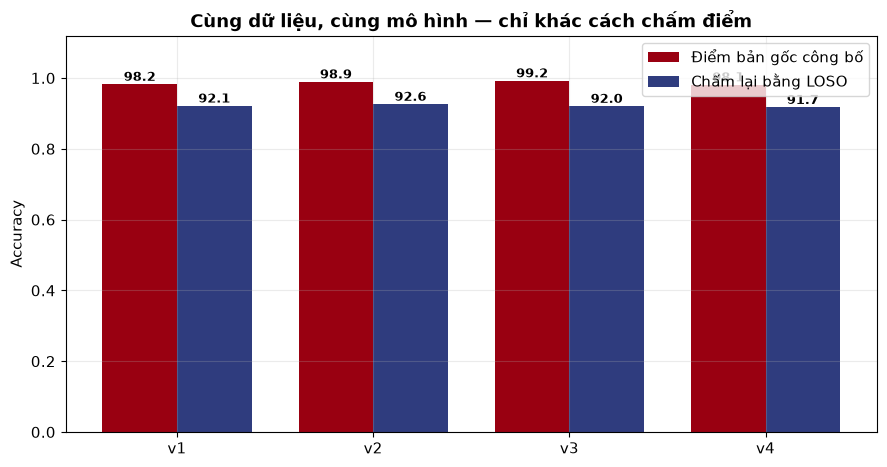

In [3]:
fig = viz.version_comparison([
    {'version': r['Phiên bản'], 'claimed': r['Chấm kiểu cũ'], 'honest': r['Chấm bằng LOSO']}
    for r in bang.to_dict(orient='records')
], title='Cùng dữ liệu, cùng mô hình — chỉ khác cách chấm điểm')
plt.show()

## Vì sao v4 vẫn là phiên bản tốt nhất?

Nếu cả bốn đều ~92% khi chấm trung thực, tại sao lại nói v4 hơn hẳn?

Vì **92% của v4 là con số nó tự công bố**, còn 92% của v1–v3 là con số ta
phải đi chấm lại giúp. Ba phiên bản đầu tin rằng mình đạt 95–99%. Nếu đem
niềm tin đó ra quyết định — chọn ngưỡng cảnh báo, hứa hẹn với bác sĩ, thiết
kế sản phẩm — thì mọi thứ dựng trên một con số sai lệch 6–7 điểm.

Ngoài ra v4 còn hai thứ v1–v3 hoàn toàn không có:

- **Kiểm định chéo bộ dữ liệu**: học trên MIMIC rồi đi thi trên AFDB (bộ dữ
  liệu khác, thiết bị khác, loại tín hiệu khác) — AUC 0.987. Đây là bằng chứng
  mô hình học "dấu hiệu của AFib" chứ không phải "đặc điểm của bộ dữ liệu".
- **Metric mức bệnh nhân**: gộp toàn bộ cửa sổ của một người thành một chẩn
  đoán. Bác sĩ chẩn đoán con người, không chẩn đoán từng đoạn 30 giây.

In [4]:
sub_rows = []
for v in versions:
    s = R[v].get('regraded_loso_subject') or {}
    if s:
        sub_rows.append({
            'Phiên bản': v,
            'Số bệnh nhân': s.get('n_subjects'),
            'Accuracy': s.get('accuracy'),
            'Recall (bắt được AFib)': s.get('recall'),
            'Specificity (không báo oan)': s.get('specificity'),
        })
pd.DataFrame(sub_rows)

,Phiên bản,Số bệnh nhân,Accuracy,Recall (bắt được AFib),Specificity (không báo oan)
0,v1,35,0.9429,1.0,0.8750
1,v2,35,0.9429,1.0,0.8750
2,v3,35,0.9714,1.0,0.9375
3,v4,35,0.9429,1.0,0.8750


### Khoan — vì sao v3 lại cao hơn v4 ở mức bệnh nhân?

Bảng trên có một chỗ dễ gây hiểu nhầm: **v3 đạt ~97% mức bệnh nhân, cao hơn
v4 (~94%)**. Vậy chẳng phải v3 tốt hơn thật sao?

Không. Lý do nằm ở **loại tín hiệu**, không phải ở phương pháp:

- v3 trích đặc trưng từ kênh **ECG** (điện tâm đồ) — tín hiệu sạch, đỉnh sóng
  R rất nhọn và dễ dò, gần như không nhiễu.
- v1, v2, v4 dùng kênh **PPG** (cảm biến quang) — đúng loại cảm biến trên vòng
  đeo tay, nhưng khó hơn nhiều: sóng tù, dễ nhiễu vì cử động và áp lực tiếp xúc.

Đo bằng ECG rồi khoe điểm cao, trong khi sản phẩm chạy bằng PPG, là so sánh
khập khiễng. **Đây chính là một trong những vấn đề của v3**, chứ không phải
điểm cộng: nó khiến mọi con số của v3 không nói lên điều gì về sản phẩm thật.

Muốn so công bằng thì phải so trên cùng loại tín hiệu — và khi đó v1/v2/v4
(cùng dùng PPG) đều quanh 94% mức bệnh nhân, ngang nhau.

## Bốn loại rò rỉ đã gặp

Mỗi phiên bản thêm một kiểu rò rỉ mới, chồng lên kiểu cũ:

| # | Kiểu rò rỉ | Xuất hiện | Bản chất |
|---|---|---|---|
| 1 | Chia ngẫu nhiên theo cửa sổ | v1 | Người ở đề thi cũng có trong bài giảng |
| 2 | Làm sạch dựa trên nhãn, áp lên cả test | v2 | Xóa những câu khó khỏi đề thi |
| 3 | Chọn ngưỡng bằng điểm test | v2 | Nhìn trộm đáp án để chỉnh tham số |
| 4 | Chuẩn hóa / lọc IQR trên toàn bộ dữ liệu | v3 | Thông tin phân bố của test lọt vào train |
| 5 | Cửa sổ chồng lấn + chia ngẫu nhiên | v3 | Bản sao gần đúng của câu hỏi nằm trong bài giảng |

**Một hiểu nhầm cần tránh:** cửa sổ chồng lấn *tự nó* không phải lỗi. v4 vẫn
dùng bước trượt 10 giây (chồng 67%). Nó chỉ nguy hiểm khi **đi kèm chia ngẫu
nhiên**. Với LOSO, mọi cửa sổ của một người nằm trọn về một phía, chồng lấn
bao nhiêu cũng không vượt được ranh giới.

In [5]:
for v in versions:
    r = R[v]
    print(f"\n{'='*66}\n{v} — {r['title']}\n{'='*66}")
    items = r.get('leakage') or []
    if items:
        for i, x in enumerate(items, 1):
            print(f'  ❌ {i}. {x}')
    for x in (r.get('fixes') or []):
        print(f'  ✅ {x}')


v1 — Đường cơ sở MIMIC PPG
  ❌ 1. Chia ngẫu nhiên theo cửa sổ: bệnh nhân ở test cũng có trong train (subject leakage).

v2 — Làm sạch dữ liệu + đặc trưng phi tuyến
  ❌ 1. Chia ngẫu nhiên theo cửa sổ (kế thừa v1).
  ❌ 2. Luật làm sạch dùng NHÃN và áp lên cả tập test -> xóa mất các ca khó.
  ❌ 3. Ngưỡng SQI được chọn bằng điểm test (xem sqi_threshold_sweep).

v3 — Benchmark đa quy mô trên kênh ECG
  ❌ 1. Cửa sổ chồng lấn tới 92%: bản sao gần đúng của mẫu test nằm trong train.
  ❌ 2. StandardScaler fit trên toàn bộ dữ liệu trước khi chia.
  ❌ 3. Lọc IQR tính ngưỡng trên toàn bộ bảng, xóa cả ca khó trong test.
  ❌ 4. Chia ngẫu nhiên theo cửa sổ, không theo bệnh nhân.
  ❌ 5. Trích đặc trưng từ kênh ECG — không phải PPG như sản phẩm thật.

v4 — Pipeline hiện hành (LOSO, chống leakage)
  ✅ LOSO theo bệnh nhân: người ở test chưa từng xuất hiện trong train.
  ✅ Scaler fit lại theo từng fold, chỉ nhìn dữ liệu train.
  ✅ Lọc IQR tính trên train và chỉ xóa hàng train; test giữ nguyên 100%.
  ✅ Ti

## Đọc tiếp

| Notebook | Nội dung |
|---|---|
| [`v1_bao_cao.ipynb`](v1_bao_cao.ipynb) | Đường cơ sở — và bằng chứng 100% bệnh nhân test nằm trong train |
| [`v2_bao_cao.ipynb`](v2_bao_cao.ipynb) | Khi "làm sạch dữ liệu" biến thành xóa câu khó khỏi đề thi |
| [`v3_bao_cao.ipynb`](v3_bao_cao.ipynb) | Bốn lỗi chồng nhau, và quy luật "càng chồng lấn điểm giả càng đẹp" |
| [`v4_bao_cao.ipynb`](v4_bao_cao.ipynb) | Cách chữa, và vì sao chấp nhận điểm thấp hơn |

Mã nguồn từng phiên bản nằm ở `src/v1/` … `src/v4/`, mỗi thư mục có README
riêng dạng "thẻ phiên bản". Tiện ích dùng chung ở `src/vlab/`.